<a href="https://colab.research.google.com/github/sivakrishnaps/AI-ML-session/blob/main/comparison_of_rf__lr__dt_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST classification using RF

In [ ]:
#loading necessary libraries
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
%matplotlib inline
# loading dataset from sklern.datasets
mnist = load_digits()

In [ ]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [ ]:
pd.DataFrame(mnist.data).head()

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [ ]:
pd.DataFrame(mnist.target).head()

,0
0,0
1,1
2,2
3,3
4,4


In [ ]:
# display image dimension
np.shape(mnist.images[1])

(8, 8)

In [ ]:
#showing the pixel values in the first image
mnist.images[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

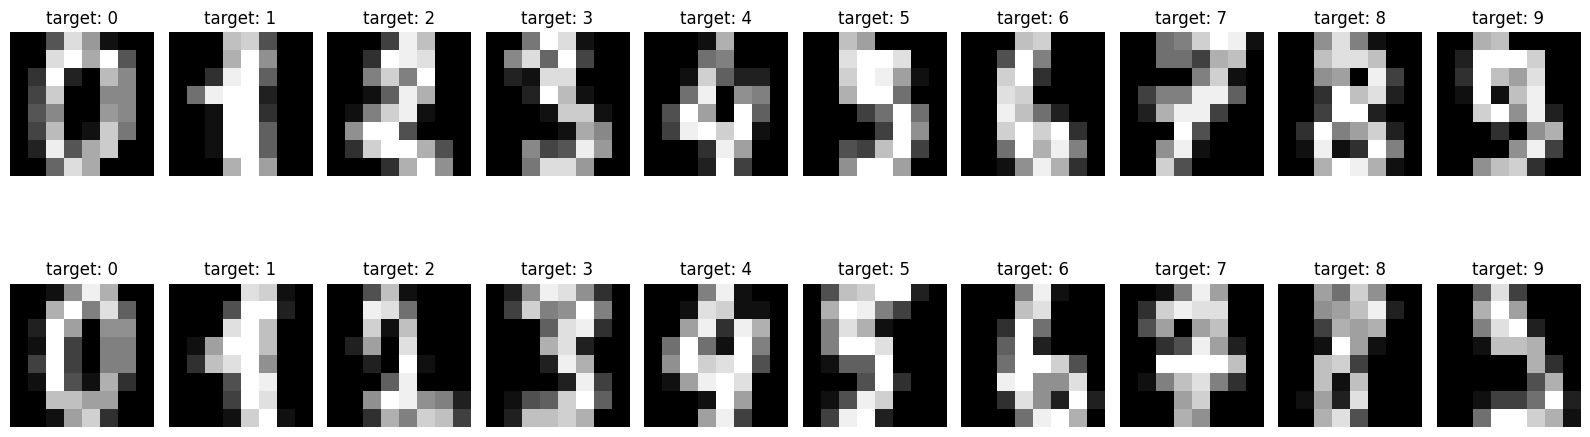

In [ ]:
fig, axes = plt.subplots(2, 10, figsize=(16, 6))
for i in range(20):
    axes[i//10, i %10].imshow(mnist.images[i], cmap='gray');
    axes[i//10, i %10].axis('off')
    axes[i//10, i %10].set_title(f"target: {mnist.target[i]}")

plt.tight_layout()

In [ ]:
# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(mnist.data, mnist.target,train_size=0.55, test_size=0.45,random_state=43)

In [ ]:
# Train a Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=40, random_state=42)
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(n_estimators=40, random_state=42)

In [ ]:
# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

In [ ]:
# Evaluate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9728059332509271


In [ ]:
from sklearn import metrics
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
print("Precision:",metrics.precision_score(y_test, y_pred,average=None))
print("Recall:",metrics.recall_score(y_test, y_pred,average=None))

Accuracy: 0.9728059332509271
Precision: [0.98876404 0.93506494 1.         1.         0.97560976 0.94444444
 0.98863636 0.93902439 0.96629213 0.98765432]
Recall: [1.         1.         0.96202532 0.96052632 0.98765432 0.95774648
 1.         1.         0.94505495 0.91954023]


In [ ]:
from sklearn.metrics import f1_score
print("f1 score for base model is : " , f1_score(y_test,y_pred,average='micro'))

f1 score for base model is :  0.9728059332509271


# classification using LR

## Machine learning part

In [ ]:
# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(mnist.data, mnist.target,train_size=0.55, test_size=0.45,random_state=43)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
# Fitting Logistic Regression to the Training set
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0, solver='lbfgs', multi_class='auto')
classifier.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='auto', random_state=0)

In [ ]:
# Predicting the Test set results
y_pred = classifier.predict(X_test)
# Predict probabilities
probs_y=classifier.predict_proba(X_test)
### Print results
probs_y = np.round(probs_y, 2)
probs_y

array([[0.  , 0.99, 0.  , ..., 0.  , 0.  , 0.  ],
       [0.  , 0.01, 0.  , ..., 0.  , 0.98, 0.  ],
       [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
       ...,
       [0.  , 0.  , 0.  , ..., 0.07, 0.7 , 0.06],
       [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , ..., 0.99, 0.  , 0.  ]])

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[88  0  0  0  0  0  0  0  0  0]
 [ 0 72  0  0  0  0  0  0  0  0]
 [ 0  1 78  0  0  0  0  0  0  0]
 [ 0  0  0 72  0  1  0  1  2  0]
 [ 0  1  0  0 78  0  0  1  0  1]
 [ 0  0  0  0  0 70  1  0  0  0]
 [ 0  0  0  0  0  0 87  0  0  0]
 [ 0  0  0  0  0  0  0 77  0  0]
 [ 0  5  0  1  1  2  0  0 81  1]
 [ 0  2  0  0  0  1  0  2  2 80]]


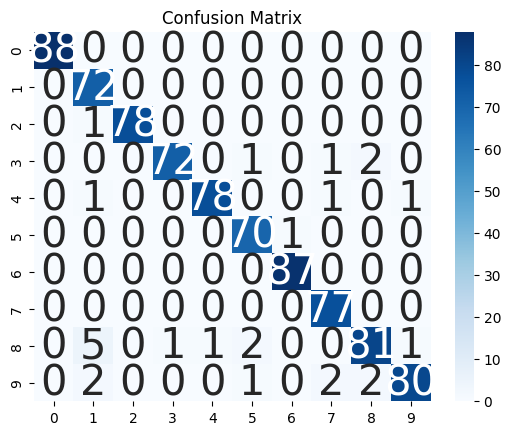

In [ ]:
# Plot confusion matrix
import seaborn as sns
# confusion matrix sns heatmap
ax = plt.axes()
df_cm = cm
sns.heatmap(df_cm, annot=True, annot_kws={"size": 30}, fmt='d',cmap="Blues", ax = ax )
ax.set_title('Confusion Matrix')
plt.show()

In [ ]:
import numpy as np

accuracy = np.trace(cm) / np.sum(cm)

print("Accuracy =", accuracy)

Accuracy = 0.9678615574783683


In [ ]:
from sklearn import metrics
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
print("Precision:",metrics.precision_score(y_test, y_pred,average=None))
print("Recall:",metrics.recall_score(y_test, y_pred,average=None))

Accuracy: 0.9678615574783683
Precision: [1.         0.88888889 1.         0.98630137 0.98734177 0.94594595
 0.98863636 0.95061728 0.95294118 0.97560976]
Recall: [1.         1.         0.98734177 0.94736842 0.96296296 0.98591549
 1.         1.         0.89010989 0.91954023]


In [ ]:
from sklearn.metrics import f1_score
print("f1 score for base model is : " , f1_score(y_test,y_pred,average='micro'))

f1 score for base model is :  0.9678615574783683


# classification using DT

## Machine learning part

In [ ]:
# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(mnist.data, mnist.target,train_size=0.55, test_size=0.45,random_state=43)

In [ ]:
# Defining an object for DTC and fitting for whole dataset
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=1 )
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=1)

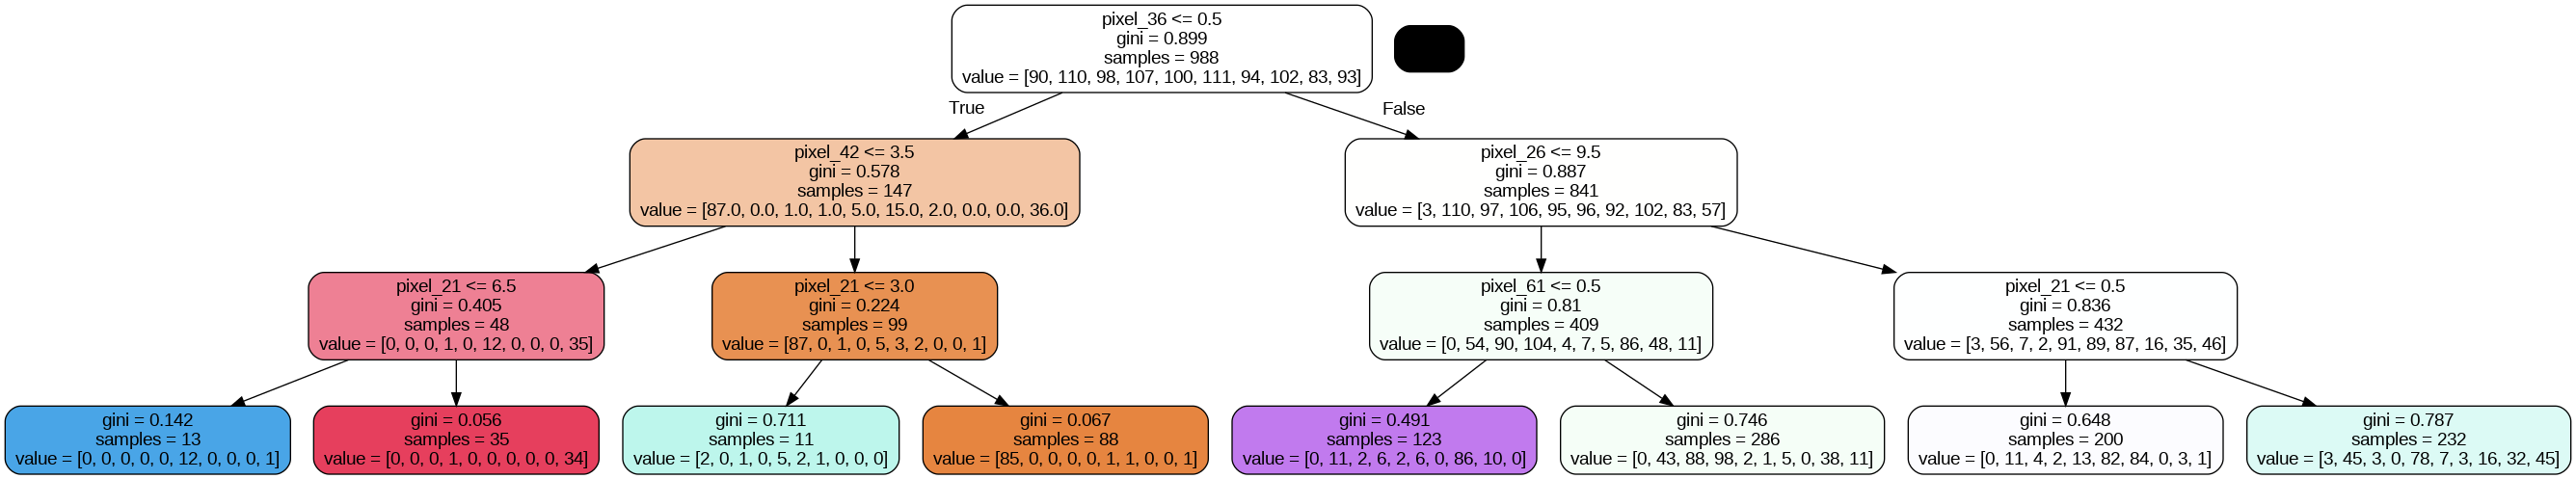

In [ ]:
# Plotting of decision tree

from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus

# Feature names
features = [f'pixel_{i}' for i in range(X_train.shape[1])]

# Export tree
dot_data = export_graphviz(
    dt,
    out_file=None,
    feature_names=features,
    filled=True,
    rounded=True
)

# Create graph
graph = pydotplus.graph_from_dot_data(dot_data)

# Display image
Image(graph.create_png())

In [ ]:
# Defining an object for DTC and fitting for train dataset
dt = DecisionTreeClassifier(random_state=1)
dt.fit(X_train, y_train)

y_pred_train = dt.predict(X_train)
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)

In [ ]:
print('Accuracy of Decision Tree-Train: ', accuracy_score(y_pred_train, y_train))
print('Accuracy of Decision Tree-Test: ', accuracy_score(y_pred, y_test))

Accuracy of Decision Tree-Train:  1.0
Accuracy of Decision Tree-Test:  0.8343634116192831


In [ ]:
#Classification for test before hyperparameter tuning
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97        88
           1       0.77      0.79      0.78        72
           2       0.85      0.84      0.84        79
           3       0.85      0.83      0.84        76
           4       0.84      0.73      0.78        81
           5       0.84      0.83      0.84        71
           6       0.83      0.87      0.85        87
           7       0.88      0.92      0.90        77
           8       0.72      0.78      0.75        91
           9       0.82      0.76      0.79        87

    accuracy                           0.83       809
   macro avg       0.84      0.83      0.83       809
weighted avg       0.83      0.83      0.83       809



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=1)

params = {
    'max_depth': [2,3,4,5],
    'min_samples_split': [2,3,4,5],
    'min_samples_leaf': [1,2,3,4,5]
}

gsearch = GridSearchCV(
    estimator=dt,
    param_grid=params,
    cv=3
)

gsearch.fit(X_train, y_train)

print(gsearch.best_params_)

{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}


In [ ]:
# Passing best parameter for the Hyperparameter Tuning
dt = DecisionTreeClassifier(**gsearch.best_params_, random_state=1)

dt.fit(X_train, y_train)

y_pred_train = dt.predict(X_train)
y_prob_train = dt.predict_proba(X_train)[:,1]

y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:,1]

In [ ]:
#Classification for test after hyperparameter tuning
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96        88
           1       0.38      0.83      0.52        72
           2       0.84      0.80      0.82        79
           3       0.76      0.76      0.76        76
           4       0.82      0.72      0.76        81
           5       0.95      0.77      0.85        71
           6       0.89      0.87      0.88        87
           7       0.98      0.84      0.91        77
           8       0.00      0.00      0.00        91
           9       0.51      0.76      0.61        87

    accuracy                           0.73       809
   macro avg       0.71      0.73      0.71       809
weighted avg       0.70      0.73      0.70       809



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print('Accuracy of Decision Tree-Train: ', accuracy_score(y_pred_train, y_train))
print('Accuracy of Decision Tree-Test: ', accuracy_score(y_pred, y_test))

Accuracy of Decision Tree-Train:  0.7955465587044535
Accuracy of Decision Tree-Test:  0.7255871446229913


##Best accuracy is achieved by Random Forest Classifier